<a href="https://colab.research.google.com/github/h3it-dias/NLP_Group_Gradientes_Backpropagation/blob/main/notebooks/Embeddings_Gradientes_Simples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Embeddings e Gradientes (versão de apresentação)

Material para uma apresentação curta sobre gradientes e backpropagation:
um passo de aprendizado numa rede mínima (embedding + linear), mostrando
`.grad` de dois parâmetros antes/depois do `backward()`, e uma intervenção
(mudar o `target`) pra ver como isso muda o gradiente.

In [1]:
import torch
from torch import nn
import torch.nn.functional as F

torch.manual_seed(0)

In [2]:
# Vocabulário e corpus
from collections import Counter

UNK_TOKEN = "<unk>"

TOY_CORPUS = [
    "o gato preto dorme no sofa",
    "o cachorro marrom corre no parque",
    "o gato branco brinca com o cachorro",
    "o cachorro late para o gato",
    "o gato mia para o cachorro",
    "a crianca brinca com o cachorro no parque",
    "a crianca brinca com o gato no sofa",
]


def tokenize(text):
    return text.lower().split()


class Vocab:
    def __init__(self, tokens):
        counts = Counter(tokens)
        self.itos = [UNK_TOKEN] + sorted(counts, key=lambda tok: (-counts[tok], tok))
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}

    def __len__(self):
        return len(self.itos)

    def encode(self, token):
        return self.stoi.get(token, self.stoi[UNK_TOKEN])

    def decode(self, index):
        return self.itos[index]


def build_vocab(corpus):
    tokens = [tok for line in corpus for tok in tokenize(line)]
    return Vocab(tokens)

# Parte 1: passo mínimo de aprendizado

A rede é `nn.Embedding` + `nn.Linear` normais — nada de decompor a
multiplicação em escalares no forward. A única diferença pro jeito mais
comum de escrever isso é que, em vez de uma chamada só a
`F.cross_entropy`, calculamos `softmax` e a perda em duas linhas
separadas, com `.retain_grad()` — só pra poder "espiar" o gradiente desses
resultados intermediários e desenhar, logo em seguida, um diagrama
detalhado do grafo (cada peso e cada componente do embedding em sua
própria caixa, com `data` e `grad` reais). O resultado matemático é
idêntico ao de `F.cross_entropy`.

In [3]:
from dataclasses import dataclass


class MinimalModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, num_classes)

    def forward(self, token_id):
        return self.linear(self.embedding(token_id))


@dataclass
class StepResult:
    model: "MinimalModel"
    word: str
    word_id: torch.Tensor
    target_class: int
    logits: torch.Tensor
    probs: torch.Tensor
    loss: torch.Tensor
    embedding_snapshot: torch.Tensor
    linear_weight_snapshot: torch.Tensor
    linear_bias_snapshot: torch.Tensor


def one_step(word="gato", target_class=1, embedding_dim=4, num_classes=2, lr=0.1):
    """Forward -> loss -> backward -> step, um único passo."""
    vocab = build_vocab(TOY_CORPUS)
    torch.manual_seed(0)
    model = MinimalModel(len(vocab), embedding_dim, num_classes)
    word_id = torch.tensor([vocab.encode(word)])
    target = torch.tensor([target_class])

    print("[Antes do backward]")
    print("  embedding.weight.grad:", model.embedding.weight.grad)
    print("  linear.weight.grad:", model.linear.weight.grad)

    logits = model(word_id)
    logits.retain_grad()
    probs = F.softmax(logits, dim=-1)
    probs.retain_grad()
    loss = F.nll_loss(torch.log(probs), target)
    loss.retain_grad()
    loss.backward()

    print("\n[Depois do backward]")
    print("  embedding.weight.grad (linha da palavra):", model.embedding.weight.grad[word_id.item()])
    print("  linear.weight.grad:\n", model.linear.weight.grad)

    # Snapshots ANTES do step(): .step() muda .data (o valor do peso), mas
    # não muda .grad. Sem esse snapshot, o diagrama mostraria o peso já
    # atualizado ao lado de contas que foram feitas com o peso antigo.
    embedding_snapshot = model.embedding.weight[word_id.item()].detach().clone()
    linear_weight_snapshot = model.linear.weight.detach().clone()
    linear_bias_snapshot = model.linear.bias.detach().clone()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    optimizer.step()

    print(f"\n[Depois do step(), SGD lr={lr}]")
    print("  embedding.weight (linha da palavra):")
    print("    antes: ", embedding_snapshot)
    print("    depois:", model.embedding.weight[word_id.item()].detach())
    print("  linear.weight[0]:")
    print("    antes: ", linear_weight_snapshot[0])
    print("    depois:", model.linear.weight[0].detach())

    return StepResult(
        model=model, word=word, word_id=word_id, target_class=target_class,
        logits=logits, probs=probs, loss=loss,
        embedding_snapshot=embedding_snapshot,
        linear_weight_snapshot=linear_weight_snapshot,
        linear_bias_snapshot=linear_bias_snapshot,
    )

In [4]:
LEAF_COLOR = "#eef2ff"
ROOT_COLOR = "#d7f5d7"
GRAD_NOT_COMPUTED = "ainda não calculado"


def _scalar(t, decimals=4):
    return f"{t.item():.{decimals}f}"


def gradient_step_graph(result, stage="depois"):
    """Reconstrói, a partir dos tensores normais do modelo (nn.Linear já
    calcula o .grad de cada peso individual sozinho), um diagrama no
    estilo do micrograd: uma caixa por peso, com data e grad reais. A
    combinação linear (pesos * entrada + bias) aparece como um único nó
    de operação, já que nn.Linear calcula isso de uma vez com um matmul —
    não existe, no grafo real de autograd, um tensor separado por
    multiplicação individual."""
    import graphviz

    show_grad = stage != "antes"
    model = result.model
    d = model.embedding.embedding_dim
    c = model.linear.out_features
    embedding_row = result.embedding_snapshot
    embedding_row_grad = model.embedding.weight.grad[result.word_id.item()] if model.embedding.weight.grad is not None else None

    def grad_text(t):
        return _scalar(t) if show_grad and t is not None else GRAD_NOT_COMPUTED

    dot = graphviz.Digraph(format="svg", graph_attr={"rankdir": "LR"})
    title = {
        "antes": "Passo mínimo de aprendizado — ANTES do backward",
        "depois": "Passo mínimo de aprendizado — DEPOIS do backward",
    }[stage]
    dot.attr(label=title, labelloc="t", fontsize="16", nodesep="0.35", ranksep="1.1", splines="polyline")
    dot.attr("node", fontname="Helvetica", fontsize="11")
    dot.attr("edge", fontname="Helvetica", fontsize="10")

    def record(node_id, label, value_text, grad_value, fillcolor=None):
        bgcolor = fillcolor or "white"
        html = (
            '<<TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" CELLPADDING="4" BGCOLOR="%s">'
            "<TR><TD>%s</TD><TD>data %s</TD><TD>grad %s</TD></TR>"
            "</TABLE>>"
        ) % (bgcolor, label, value_text, grad_text(grad_value))
        dot.node(node_id, html, shape="none")

    def order_top_to_bottom(node_ids, graph=dot):
        with graph.subgraph() as s:
            s.attr(rank="same")
            for node_id in node_ids:
                s.node(node_id)
            for a, b in zip(node_ids, node_ids[1:]):
                s.edge(a, b, style="invis")

    leaf_order = []
    for i in range(d):
        e_i = embedding_row[i]
        e_i_grad = embedding_row_grad[i] if embedding_row_grad is not None else None
        record(f"e{i}", f"e{i} (embedding[\'{result.word}\'][{i}])", _scalar(e_i), e_i_grad, LEAF_COLOR)
        leaf_order.append(f"e{i}")

    for j in range(c):
        for i in range(d):
            leaf_order.append(f"w{j}_{i}")
        leaf_order.append(f"bias{j}")

    for j in range(c):
        for i in range(d):
            w_ji = result.linear_weight_snapshot[j, i]
            w_ji_grad = model.linear.weight.grad[j, i] if model.linear.weight.grad is not None else None
            record(f"w{j}_{i}", f"w[{j}][{i}]", _scalar(w_ji), w_ji_grad, LEAF_COLOR)

        bias_j = result.linear_bias_snapshot[j]
        bias_j_grad = model.linear.bias.grad[j] if model.linear.bias.grad is not None else None
        record(f"bias{j}", f"linear.bias[{j}]", _scalar(bias_j), bias_j_grad, LEAF_COLOR)

        logit_j = result.logits[0, j]
        logit_j_grad = result.logits.grad[0, j] if result.logits.grad is not None else None
        record(f"logit{j}", f"logit[{j}]", _scalar(logit_j), logit_j_grad)

        dot.node(f"combine{j}", "Σ w·e + b")
        for i in range(d):
            dot.edge(f"e{i}", f"combine{j}")
            dot.edge(f"w{j}_{i}", f"combine{j}")
        dot.edge(f"bias{j}", f"combine{j}")
        dot.edge(f"combine{j}", f"logit{j}")

        with dot.subgraph(name=f"cluster_neuron{j}") as cluster:
            cluster.attr(label=f"Neurônio {j} (classe {j})", style="rounded", color="gray50", fontsize="12")
            cluster.node(f"combine{j}")

    dot.node("op_softmax", "softmax")
    for j in range(c):
        dot.edge(f"logit{j}", "op_softmax")

    for j in range(c):
        prob_j = result.probs[0, j]
        prob_j_grad = result.probs.grad[0, j] if result.probs.grad is not None else None
        fill = ROOT_COLOR if j == result.target_class else None
        record(f"prob{j}", f"prob[{j}]{' (classe alvo)' if j == result.target_class else ''}", _scalar(prob_j), prob_j_grad, fill)
        dot.edge("op_softmax", f"prob{j}")

    dot.node("op_nll", "-log")
    dot.edge(f"prob{result.target_class}", "op_nll")
    record("loss", "loss", _scalar(result.loss), result.loss.grad, ROOT_COLOR)
    dot.edge("op_nll", "loss")

    order_top_to_bottom(leaf_order)
    order_top_to_bottom([f"combine{j}" for j in range(c)])
    order_top_to_bottom([f"logit{j}" for j in range(c)])
    order_top_to_bottom([f"prob{j}" for j in range(c)])

    return dot

In [5]:
baseline = one_step()

[Antes do backward]
  embedding.weight.grad: None
  linear.weight.grad: None

[Depois do backward]
  embedding.weight.grad (linha da palavra): tensor([ 0.0579,  0.0440, -0.0561, -0.0195])
  linear.weight.grad:
 tensor([[ 0.0641,  0.6622,  0.5975, -0.1323],
        [-0.0641, -0.6622, -0.5975,  0.1323]])

[Depois do step(), SGD lr=0.1]
  embedding.weight (linha da palavra):
    antes:  tensor([ 0.1198,  1.2377,  1.1168, -0.2473])
    depois: tensor([ 0.1140,  1.2333,  1.1224, -0.2453])
  linear.weight[0]:
    antes:  tensor([ 0.3579,  0.1870, -0.4949, -0.3243])
    depois: tensor([ 0.3515,  0.1207, -0.5546, -0.3111])


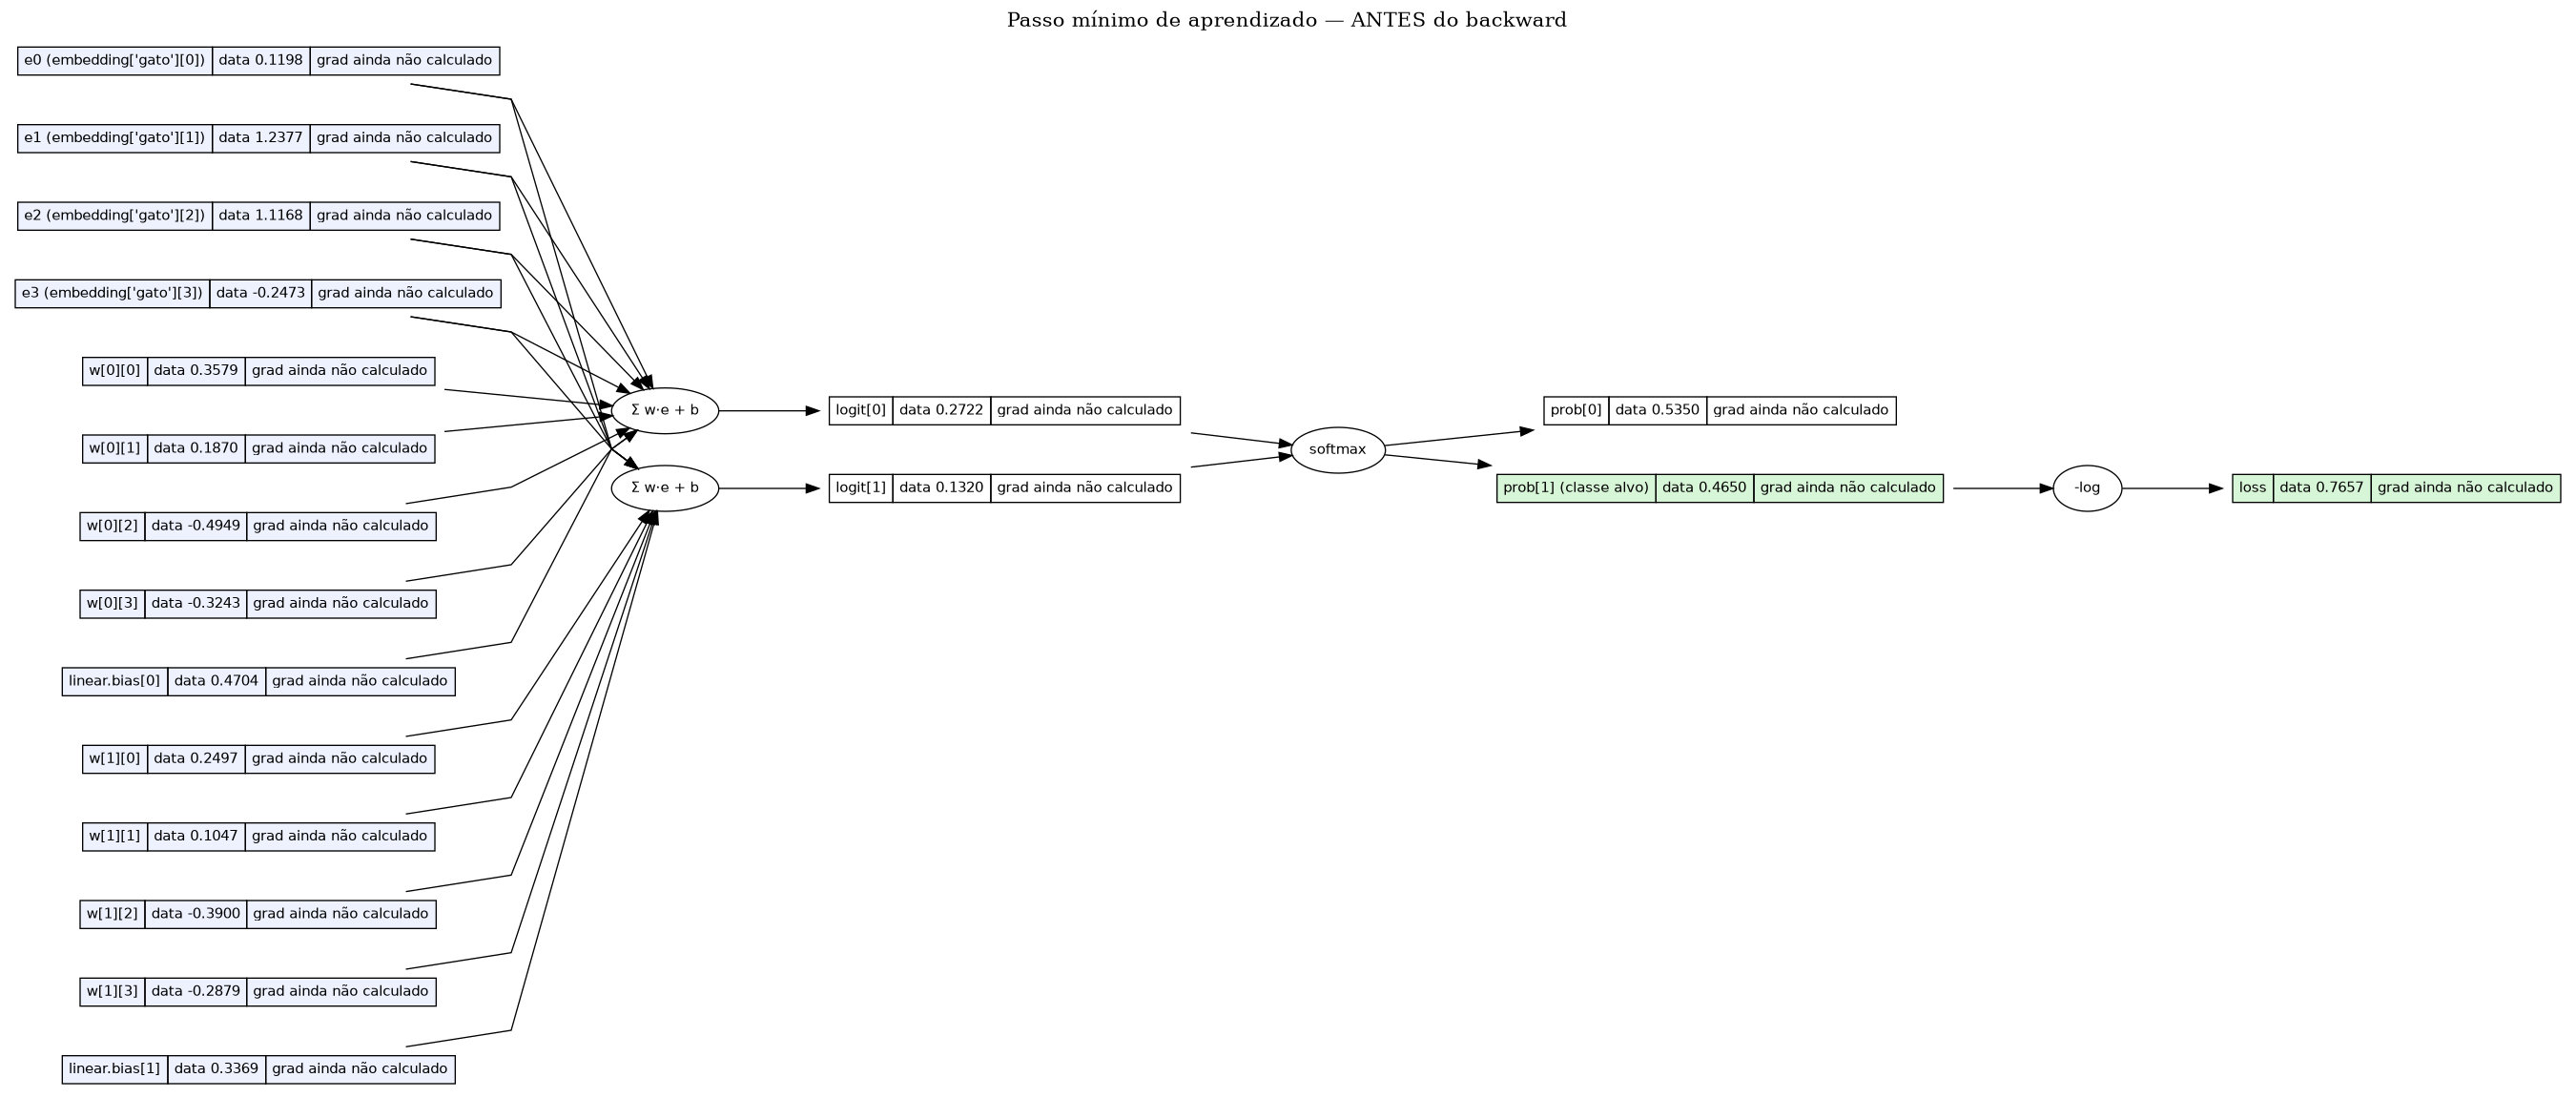

In [6]:
graph_antes = gradient_step_graph(baseline, stage='antes')
graph_antes

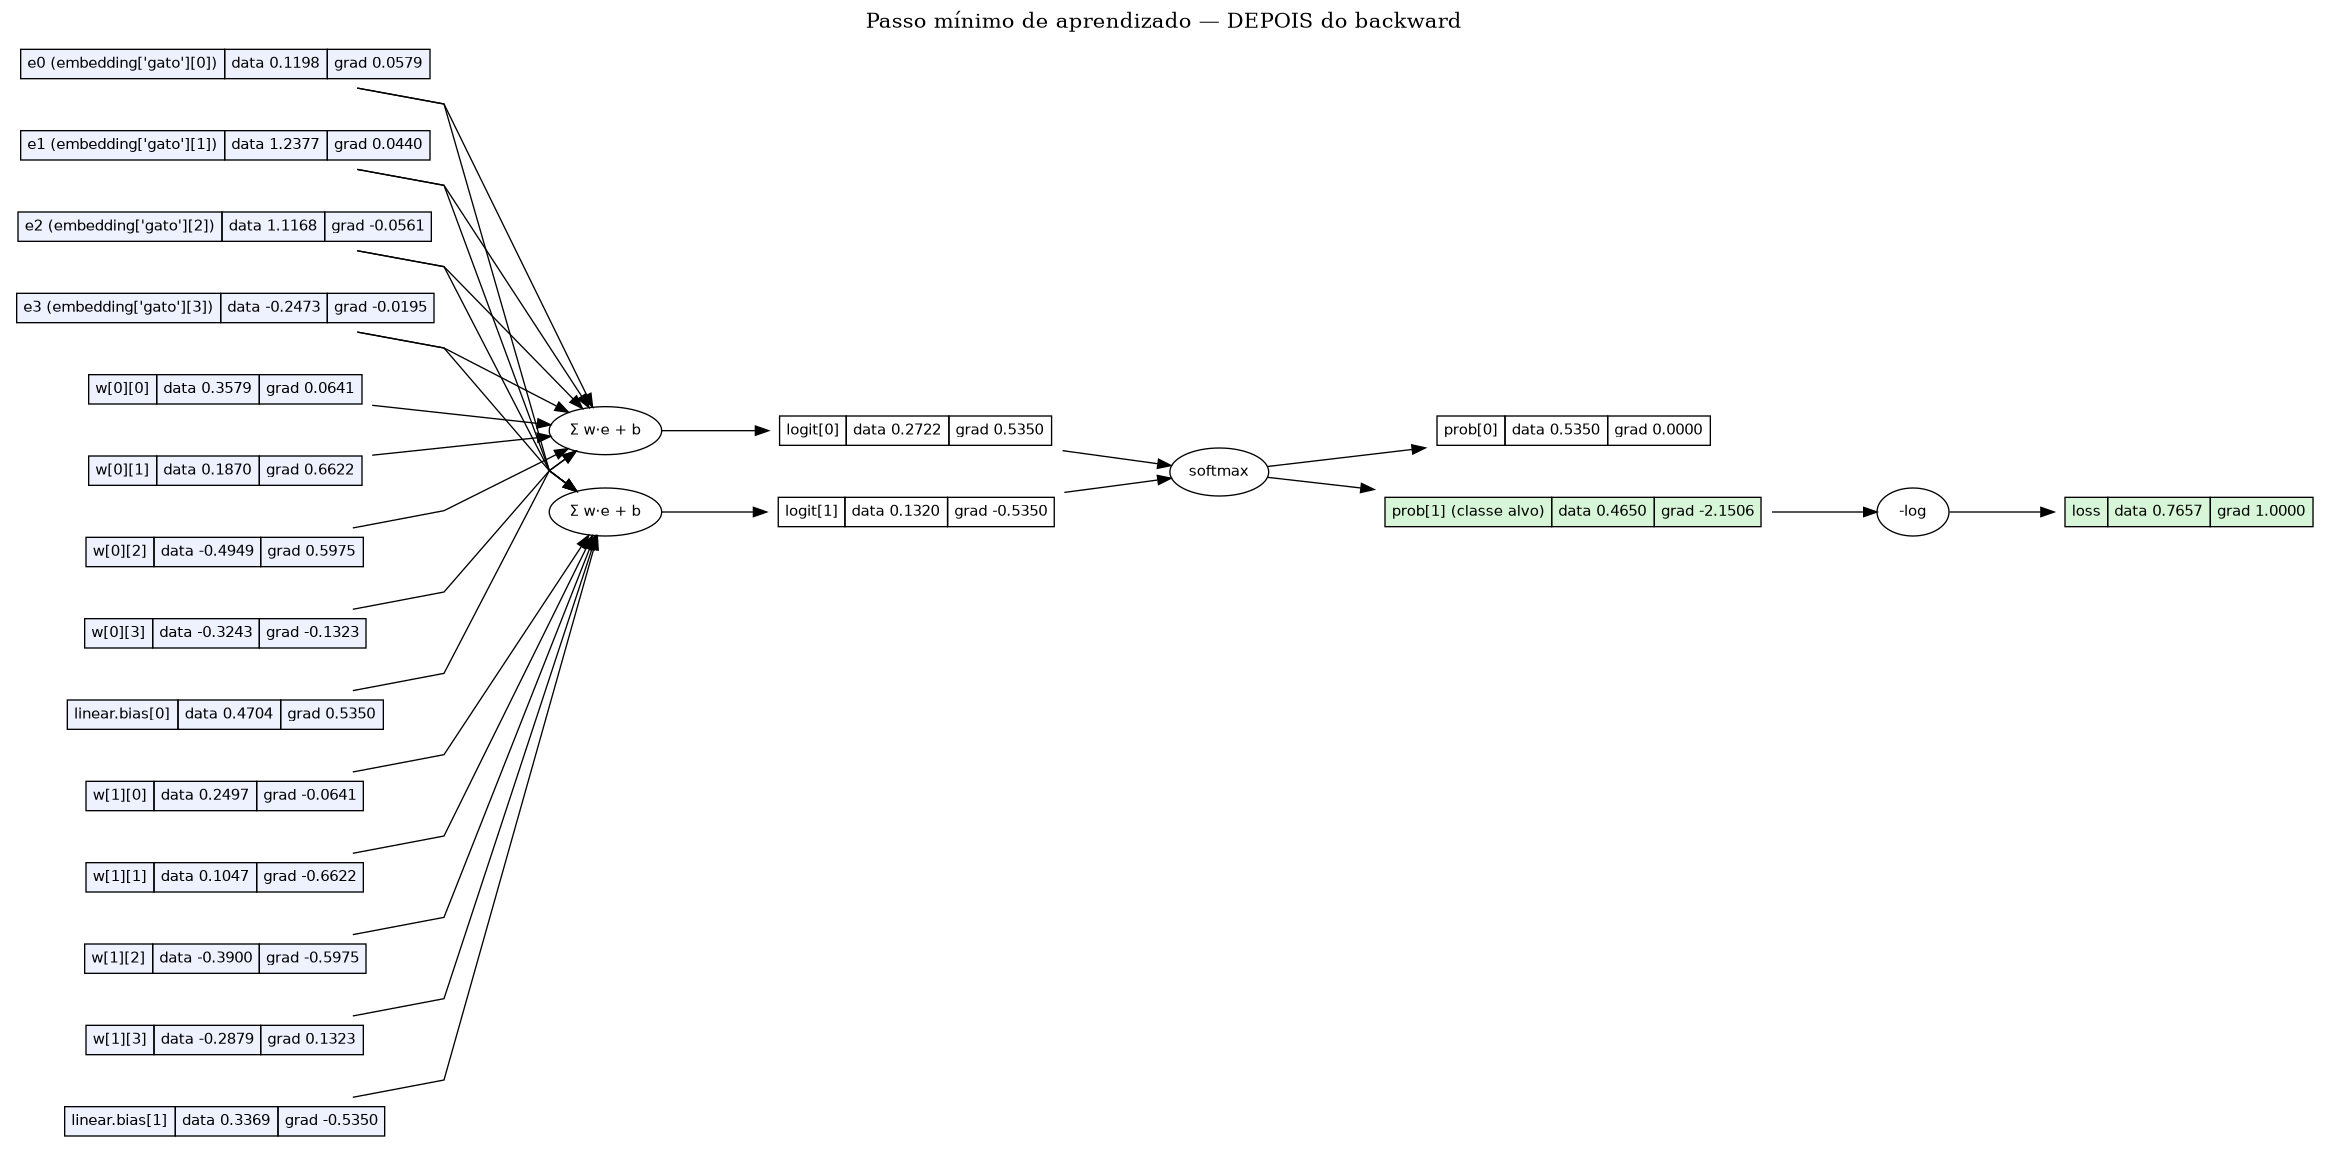

In [7]:
graph_depois = gradient_step_graph(baseline, stage='depois')
graph_depois

`.backward()` só **calcula** os gradientes (preenche `.grad`); quem
**altera** os pesos é o `optimizer.step()`, usando a fórmula
`peso ← peso - lr × grad`. São duas etapas separadas — é fácil assumir que
`backward()` já treina a rede, mas ele não muda peso nenhum sozinho.

**Como ler os números do diagrama:** o nó `Σ w·e + b` de cada neurônio
combina todos os pesos, o embedding e o bias numa única operação (é o que
`nn.Linear` faz internamente com um matmul). Mesmo sem aparecer decomposto
em multiplicações separadas, o gradiente de cada peso individual
(`w[j][i].grad`) já vem calculado corretamente pelo PyTorch, e é diferente
para cada peso — pela regra do produto, `∂loss/∂w[j][i]` é o gradiente que
chegou em `logit[j]` multiplicado pelo valor de `e_i` correspondente.

# Parte 2: intervenção

Rodando o mesmo passo duas vezes, mudando só o `target` (a "resposta
certa"), com a mesma inicialização de pesos (`one_step` fixa a seed).
Comparamos como isso muda o gradiente.

In [8]:
result_a = one_step(target_class=1)
print("\n" + "=" * 60 + "\n")
result_b = one_step(target_class=0)

print("\n########## COMPARAÇÃO ##########")
print(f"loss (target=1): {result_a.loss.item():.4f}")
print(f"loss (target=0): {result_b.loss.item():.4f}")
print("grad embedding (target=1):", result_a.model.embedding.weight.grad[result_a.word_id.item()])
print("grad embedding (target=0):", result_b.model.embedding.weight.grad[result_b.word_id.item()])

[Antes do backward]
  embedding.weight.grad: None
  linear.weight.grad: None

[Depois do backward]
  embedding.weight.grad (linha da palavra): tensor([ 0.0579,  0.0440, -0.0561, -0.0195])
  linear.weight.grad:
 tensor([[ 0.0641,  0.6622,  0.5975, -0.1323],
        [-0.0641, -0.6622, -0.5975,  0.1323]])

[Depois do step(), SGD lr=0.1]
  embedding.weight (linha da palavra):
    antes:  tensor([ 0.1198,  1.2377,  1.1168, -0.2473])
    depois: tensor([ 0.1140,  1.2333,  1.1224, -0.2453])
  linear.weight[0]:
    antes:  tensor([ 0.3579,  0.1870, -0.4949, -0.3243])
    depois: tensor([ 0.3515,  0.1207, -0.5546, -0.3111])


[Antes do backward]
  embedding.weight.grad: None
  linear.weight.grad: None

[Depois do backward]
  embedding.weight.grad (linha da palavra): tensor([-0.0503, -0.0383,  0.0487,  0.0169])
  linear.weight.grad:
 tensor([[-0.0557, -0.5755, -0.5193,  0.1150],
        [ 0.0557,  0.5755,  0.5193, -0.1150]])

[Depois do step(), SGD lr=0.1]
  embedding.weight (linha da palavra):


Os gradientes saem com sinal invertido: para cross-entropy com softmax, `∂loss/∂logit_j = prob[j] - 1` se `j` for a classe certa, ou só `prob[j]` caso contrário. Mudar o alvo muda qual logit recebe o `-1`, e isso se propaga pra trás por toda a rede.